# proximal_lab — end-to-end walkthrough (PPO + GAE on MuJoCo)

Six cells: load env → build network → short PPO training → evaluate → load sweep results → run the Graphify tool.

Open this from `assignment4/` with `jupyter notebook notebooks/proximal_lab_walkthrough.ipynb`. The SDK resolves paths from the project root.

## 1 — Load the SDK and build a MuJoCo env

`ProximalLab(config_path)` reads `configs/setup.json`, seeds Python/NumPy/PyTorch, and gives us a single facade. `make_env` from `env_builder` builds a `SyncVectorEnv` with the running-mean / running-std observation normaliser.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in Path.cwd().resolve().parents if (p / 'configs' / 'setup.json').exists()) \
       if not (Path.cwd() / 'configs' / 'setup.json').exists() else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from proximal_lab.sdk.sdk import ProximalLab
from proximal_lab.sdk.env_builder import build_vector_env

sdk = ProximalLab(config_path=ROOT / 'configs' / 'setup.json')
env = build_vector_env(sdk.config, env_id='HalfCheetah-v5', seed=0)
print(f'env: HalfCheetah-v5  obs={env.observation_space.shape}  action={env.action_space.shape}  n_envs={env.n_envs}')

env: HalfCheetah-v5  obs=(17,)  action=(6,)  n_envs=4


## 2 — Build the actor-critic network

Diagonal Gaussian policy with state-independent log-std + scalar critic. Orthogonal init from Engstrom 2020 (hidden gain √2, actor head 0.01, critic head 1.0).

In [2]:
from proximal_lab.sdk.trainers import build_actor_critic, build_ppo_service

net = build_actor_critic(sdk.config, obs_dim=env.observation_space.shape[0],
                           action_dim=env.action_space.shape[0])
n_params = sum(p.numel() for p in net.parameters())
print(f'ActorCriticNet — {n_params} params, hidden_sizes={net.hidden_sizes}')
print(f'actor params: {sum(p.numel() for p in net.actor_params())}')
print(f'critic params: {sum(p.numel() for p in net.critic_params())}')

ActorCriticNet — 11085 params, hidden_sizes=(64, 64)
actor params: 5708
critic params: 5377


## 3 — Quick PPO training

Short 4096-step run so the notebook executes in seconds; bump in `configs/setup.json:ppo.total_timesteps` for a serious run.

In [3]:
svc = build_ppo_service(sdk.config)
result = svc.fit(net, env, total_timesteps=4096, steps_per_rollout=1024)
rewards = [d.mean_episode_reward for d in result.diagnostics]
print(f'iterations: {len(result.diagnostics)}, final mean reward: {result.final_mean_reward:.2f}')
print('per-iter reward trajectory:', [round(r, 2) for r in rewards])

2026-06-09 23:17:48 INFO    [proximal_lab.services.ppo_service] iter=0 ts=4096 ep_reward=-283.23 kl=0.0130 clip_frac=0.161 ev=-0.010


iterations: 1, final mean reward: -283.23
per-iter reward trajectory: [-283.23]


## 4 — Plot the three slide-21 stability pillars

Per-iteration: episode reward (Loop), explained variance (Signal — advantage quality), clip fraction (Policy — proximal step bound).

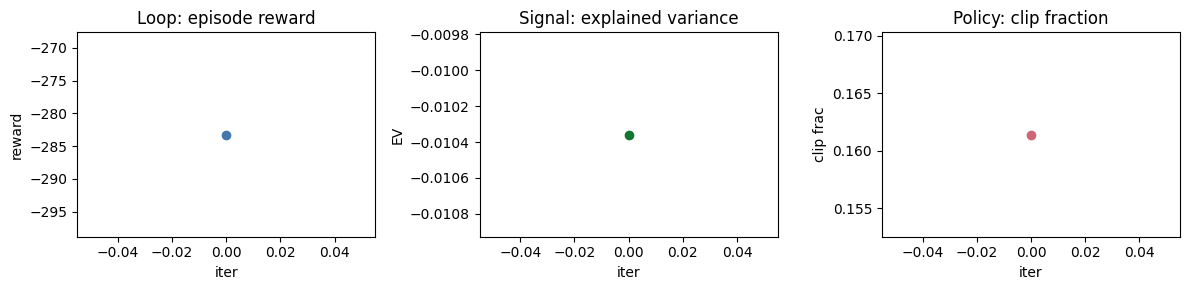

In [4]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
iters = [d.iteration for d in result.diagnostics]
axes[0].plot(iters, [d.mean_episode_reward for d in result.diagnostics], '-o', color='#4477aa')
axes[0].set(title='Loop: episode reward', xlabel='iter', ylabel='reward')
axes[1].plot(iters, [d.explained_variance for d in result.diagnostics], '-o', color='#117733')
axes[1].set(title='Signal: explained variance', xlabel='iter', ylabel='EV')
axes[2].plot(iters, [d.clip_fraction for d in result.diagnostics], '-o', color='#cc6677')
axes[2].set(title='Policy: clip fraction', xlabel='iter', ylabel='clip frac')
fig.tight_layout(); plt.show()

## 5 — Load the Layer-10 sweep results

The headline λ-sweep — empirical proof of slide-16's bias-variance dial. Inverted-U around λ=0.95.

Sweep: lambda_sweep — 6 cells
  lambda=0.0: final=-258.88 ± 0.00
  lambda=0.5: final=-230.03 ± 0.00
  lambda=0.9: final=-238.69 ± 0.00
  lambda=0.95: final=-226.30 ± 0.00
  lambda=0.99: final=-252.57 ± 0.00
  lambda=1.0: final=-268.89 ± 0.00


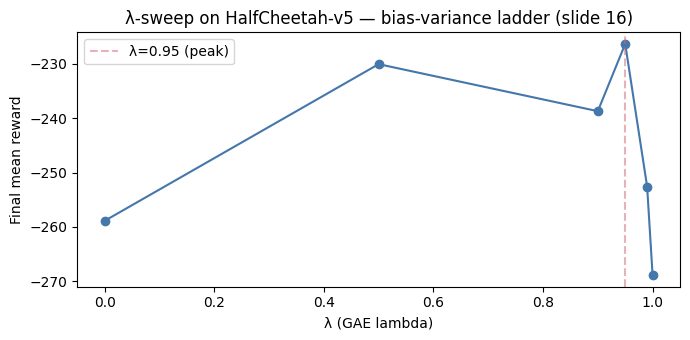

In [5]:
import json
sweep = json.loads((ROOT / 'results' / 'sweeps' / 'lambda.json').read_text())
print(f'Sweep: {sweep["label"]} — {len(sweep["cells"])} cells')
for cell in sweep['cells']:
    print(f'  {cell["name"]}: final={cell["final_reward_mean"]:.2f} '
          f'± {cell["final_reward_ci_95"]:.2f}')

lambdas = [float(c['name'].split('=')[1]) for c in sweep['cells']]
finals = [c['final_reward_mean'] for c in sweep['cells']]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(lambdas, finals, '-o', color='#4477aa')
ax.set(xlabel='λ (GAE lambda)', ylabel='Final mean reward',
       title='λ-sweep on HalfCheetah-v5 — bias-variance ladder (slide 16)')
ax.axvline(0.95, color='#cc6677', linestyle='--', alpha=0.5, label='λ=0.95 (peak)')
ax.legend(); fig.tight_layout(); plt.show()

## 6 — Build the Obsidian wiki via the mini-Graphify tool

The Active Knowledge Architecture realisation — walks the project's Python AST and emits Wikilinks. Open `docs/wiki/` in Obsidian for the graph view.

In [6]:
from proximal_lab.tools.graphify.runner import run_graphify
run_graphify(sdk.config)
graph = json.loads((ROOT / 'docs' / 'wiki' / 'graph.json').read_text())
modules = [n for n in graph['nodes'] if n['type'] == 'module']
classes = [n for n in graph['nodes'] if n['type'] == 'class']
functions = [n for n in graph['nodes'] if n['type'] == 'function']
imports = [e for e in graph['edges'] if e['type'] == 'imports']
print(f'wiki: {len(modules)} modules, {len(classes)} classes, {len(functions)} functions, {len(imports)} import edges')

2026-06-09 23:17:49 INFO    [proximal_lab.tools.graphify.runner] graphify wrote 73 nodes + 137 edges to /home/corsight/src/RL_Course/assignment4/docs/wiki


wiki: 26 modules, 24 classes, 23 functions, 90 import edges


## What's next?

- Run `scripts/run_sweeps.py` for the full λ/γ/clip-ε sweep at 20k timesteps/cell.
- Run `scripts/run_cross_env.py` for the HalfCheetah → Walker2d transfer.
- See `README.md` § 9 for the audit-driven analysis.